In [35]:
import gc
import math
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from timm.data import resolve_model_data_config, create_transform
from tqdm.auto import tqdm


# Utils


In [36]:
def describe_dataset(name, dataset, batch_size=8):
    base_ds = dataset.ds if hasattr(dataset, "ds") else dataset

    print(f"## {name}")
    print(f"num_samples: {len(dataset):,}")

    if hasattr(base_ds, "classes"):
        print(f"num_classes: {len(base_ds.classes)}")
        print("classes:")
        for i, cls in enumerate(base_ds.classes):
            cls_name = cls[0] if isinstance(cls, (tuple, list)) else cls
            print(f"  {i}: {cls_name}")

    if hasattr(base_ds, "_labels"):
        labels = list(base_ds._labels)
    elif hasattr(base_ds, "targets"):
        labels = list(base_ds.targets)
    else:
        labels = [base_ds[i][1] for i in range(len(base_ds))]

    counts = Counter(labels)
    print("class_counts:")
    for k in sorted(counts):
        cls = base_ds.classes[k] if hasattr(base_ds, "classes") else str(k)
        cls_name = cls[0] if isinstance(cls, (tuple, list)) else cls
        print(f"  {k:2d} {cls_name:20s}: {counts[k]:,}")

    x, y = dataset[0]
    print("\nfirst transformed sample:")
    print(f"  x type: {type(x)}")
    print(f"  x shape: {tuple(x.shape) if torch.is_tensor(x) else None}")
    print(f"  x dtype: {x.dtype if torch.is_tensor(x) else None}")
    print(f"  x min/max: {x.min().item():.4f} / {x.max().item():.4f}")
    print(f"  x mean/std: {x.mean().item():.4f} / {x.std().item():.4f}")
    print(f"  y: {y}")

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    xb, yb = next(iter(loader))
    print("\nfirst batch:")
    print(f"  xb shape: {tuple(xb.shape)}")
    print(f"  xb dtype: {xb.dtype}")
    print(f"  yb shape: {tuple(yb.shape)}")
    print(f"  yb[:{batch_size}]: {yb.tolist()}")


@torch.no_grad()
def compute_mean_bias(X):
    return X.float().mean(dim=0)


@torch.no_grad()
def compute_geometric_median(X: torch.Tensor, max_iter=100, tol=1e-5, eps=1e-8):
    X = X.float()
    y = X.mean(dim=0)
    print("Calculating Geometric Median....")
    for _ in tqdm(range(int(max_iter)), desc="geometric median"):
        distances = torch.norm(X - y, dim=1).clamp_min(eps)
        weights = 1.0 / distances
        y_next = (X * weights[:, None]).sum(dim=0) / weights.sum()
        if torch.norm(y_next - y).item() < float(tol):
            y = y_next
            break
        y = y_next
    print("Complete!")
    return y


# HypreParams


In [37]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# SAE Setting
EXPANSION = 64
DEC_BIAS_MODE = "geom"
SAE_ACTIVE_THRESHOLD = 0.2

# Training hyperparameters
TARGET_BLOCK = 9          # vit_b.blocks[11]
TOKEN_SCOPE = "all"       # "cls", "patch", "all"
MAX_TRAIN_TOKENS = 50_000  # None means stream over all train tokens
MAX_VAL_TOKENS = 10_000
BS = 128
EPOCHS = 300
L1_REG = 8e-5
SAE_LR = 1e-4
SAE_BATCH_SIZE = 512
TOKEN_CACHE_DTYPE = torch.float16
TOKEN_NORMALIZE_CHUNK_SIZE = 65_536
BIAS_INIT_GEOM_MAX_ITER = 100
BIAS_INIT_GEOM_TOL = 1e-5

if (not TARGET_BLOCK == 11) and (not TOKEN_SCOPE.lower() == 'patch'):
    TOKEN_SCOPE = 'patch'

# SAE


In [38]:
class VanillaL1SAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, X_train=None, b_dec_init: torch.Tensor = None, dec_bias_mode="zero"):
        super().__init__()
        self.input_dim = int(input_dim)
        self.hidden_dim = int(hidden_dim)
        self.dec_bias_mode = str(dec_bias_mode).lower()

        if b_dec_init is not None:
            b_dec_init = b_dec_init.detach().float()
        elif X_train is not None:
            if self.dec_bias_mode == "mean":
                b_dec_init = compute_mean_bias(X_train)
            elif self.dec_bias_mode == "geom":
                b_dec_init = compute_geometric_median(X_train)
            elif self.dec_bias_mode == "zero":
                b_dec_init = torch.zeros(self.input_dim)
            else:
                raise ValueError(f"Unknown dec_bias_mode: {self.dec_bias_mode}")
        elif self.dec_bias_mode == "zero":
            b_dec_init = torch.zeros(self.input_dim)
        elif self.dec_bias_mode in {"mean", "geom"}:
            raise ValueError("X_train or b_dec_init is required for mean/geometric median b_dec initialization.")
        else:
            raise ValueError(f"Unknown dec_bias_mode: {self.dec_bias_mode}")

        self.W_enc = nn.Parameter(torch.empty(self.input_dim, self.hidden_dim))
        self.b_enc = nn.Parameter(torch.zeros(self.hidden_dim))
        self.W_dec = nn.Parameter(torch.empty(self.hidden_dim, self.input_dim))
        self.b_dec = nn.Parameter(torch.empty(self.input_dim))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        with torch.no_grad():
            self.W_dec.div_(self.W_dec.norm(dim=1, keepdim=True).clamp_min(1e-8))
            self.b_dec.copy_(b_dec_init.reshape(-1).to(dtype=self.b_dec.dtype, device=self.b_dec.device))

    def encode(self, x: torch.Tensor):
        sae_in = x.to(self.W_enc.dtype) - self.b_dec
        return F.relu(sae_in @ self.W_enc + self.b_enc)

    def decode(self, z: torch.Tensor):
        return z.to(self.W_dec.dtype) @ self.W_dec + self.b_dec

    @torch.no_grad()
    def set_decoder_norm_to_unit_norm(self, eps=1e-8):
        self.W_dec.div_(self.W_dec.norm(dim=1, keepdim=True).clamp_min(eps))

    @torch.no_grad()
    def remove_gradient_parallel_to_decoder_directions(self):
        if self.W_dec.grad is None:
            return
        parallel_component = (self.W_dec.grad * self.W_dec.data).sum(dim=1, keepdim=True)
        self.W_dec.grad.sub_(parallel_component * self.W_dec.data)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z


In [39]:
class DS(Dataset):
    def __init__(self, ds, transform=None):
        self.ds = ds
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        x, y = self.ds[idx]
        if self.transform:
            x = self.transform(x)
        return x, y


# 1. Target Model Load (vit-b 16)


In [40]:
vit_b = timm.create_model("vit_base_patch16_224", pretrained=True)
vit_b.eval()
data_config = resolve_model_data_config(vit_b)
vit_b_transformer = create_transform(**data_config, is_training=False)
print(vit_b_transformer)


Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.5000, 0.5000, 0.5000]), std=tensor([0.5000, 0.5000, 0.5000]))
)


# 2. Data Load and Descibe


In [ ]:
from torchvision.datasets import Imagenette

train_ds = DS(Imagenette(root="data", split="train", download=False), transform=vit_b_transformer)
test_ds = DS(Imagenette(root="data", split="val", download=False), transform=vit_b_transformer)

describe_dataset("train_ds", train_ds)
describe_dataset("test_ds", test_ds)


## train_ds
num_samples: 9,469
num_classes: 10
classes:
  0: tench
  1: English springer
  2: cassette player
  3: chain saw
  4: church
  5: French horn
  6: garbage truck
  7: gas pump
  8: golf ball
  9: parachute


In [ ]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)


In [ ]:
def visualize_imagenette_samples(ds: DS, indices=None, n=12, cols=4, seed=0, figsize=None):
    dataset = ds.ds
    if indices is None:
        rng = np.random.default_rng(seed)
        count = min(n, len(dataset))
        indices = rng.choice(len(dataset), size=count, replace=False).tolist()
    else:
        indices = list(indices)[:n]

    if not indices:
        raise ValueError("No indices to visualize.")

    rows = math.ceil(len(indices) / cols)
    if figsize is None:
        figsize = (3.0 * cols, 3.4 * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.asarray(axes).reshape(-1)

    for ax, idx in zip(axes, indices):
        image, target = dataset[int(idx)]
        class_name = dataset.classes[int(target)]
        if isinstance(class_name, (tuple, list)):
            class_name = class_name[0]
        ax.imshow(image)
        ax.set_title(f"#{int(idx)} | {class_name}", fontsize=10)
        ax.axis("off")

    for ax in axes[len(indices):]:
        ax.axis("off")

    fig.tight_layout()
    return fig


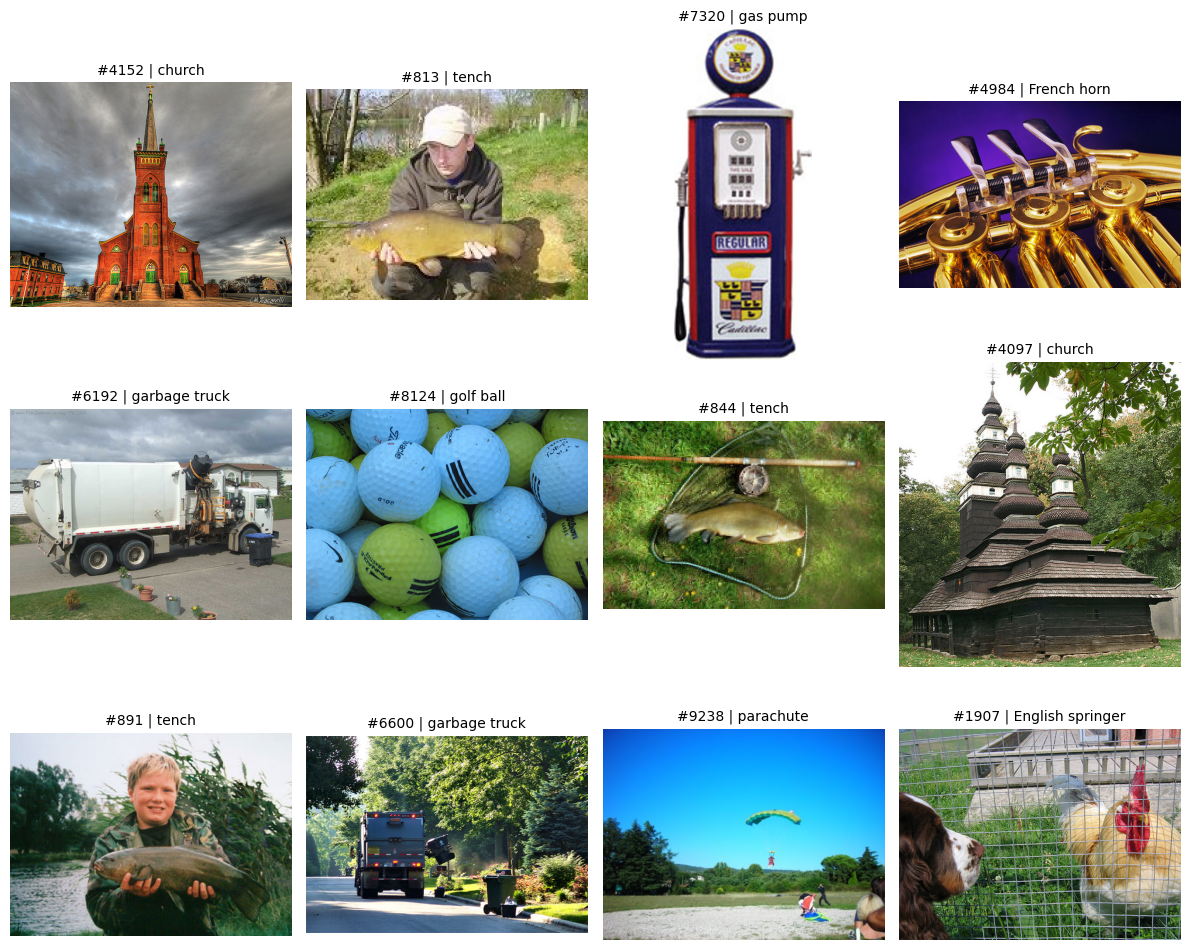

In [ ]:
visualize_imagenette_samples(train_ds, n=12, seed=42)
plt.show()


# 


# SAE Training


In [ ]:
# SAE training and validation from a ViT block hook

def select_block_tokens(block_output: torch.Tensor, token_scope=TOKEN_SCOPE):
    if isinstance(block_output, (tuple, list)):
        block_output = block_output[0]
    if block_output.ndim != 3:
        raise ValueError(f'Expected block output [B, tokens, dim], got {tuple(block_output.shape)}.')

    if token_scope == 'cls':
        tokens = block_output[:, :1]
    elif token_scope == 'patch':
        tokens = block_output[:, 1:]
    elif token_scope in {'all', 'clspatch'}:
        tokens = block_output
    else:
        raise ValueError("TOKEN_SCOPE must be one of: 'cls', 'patch', 'all', 'clspatch'.")
    return tokens.reshape(-1, tokens.shape[-1]).detach().float().cpu()


def normalize_tokens(tokens, stats):
    return (tokens - stats['mean']) / stats['std']


def normalize_tokens_inplace(tokens, stats):
    tokens.sub_(stats['mean'])
    tokens.div_(stats['std'])
    return tokens


@torch.no_grad()
def collect_tokens_with_hook(model, loader, max_tokens, target_block=TARGET_BLOCK, token_scope=TOKEN_SCOPE, device=DEVICE, return_labels=False):
    model.eval().to(device)
    if target_block < 0 or target_block >= len(model.blocks):
        raise ValueError(f'TARGET_BLOCK={target_block} is outside model.blocks length {len(model.blocks)}.')

    token_chunks = []
    label_chunks = []
    captured = {}
    total = 0

    def hook(_module, _inputs, output):
        captured['tokens'] = select_block_tokens(output, token_scope=token_scope)

    handle = model.blocks[target_block].register_forward_hook(hook)
    try:
        for images, labels in tqdm(loader, desc='collecting ViT block tokens'):
            captured.clear()
            _ = model(images.to(device))
            tokens = captured['tokens']
            tokens_per_image = max(1, tokens.shape[0] // images.shape[0])

            if max_tokens is not None:
                remaining = int(max_tokens) - total
                if remaining <= 0:
                    break
                tokens = tokens[:remaining]

            token_chunks.append(tokens.to(TOKEN_CACHE_DTYPE if TOKEN_CACHE_DTYPE is not None else torch.float32))
            if return_labels:
                expanded_labels = labels.repeat_interleave(tokens_per_image)[:tokens.shape[0]].detach().cpu()
                label_chunks.append(expanded_labels)

            total += tokens.shape[0]
            if max_tokens is not None and total >= int(max_tokens):
                break
    finally:
        handle.remove()

    if not token_chunks:
        raise RuntimeError('No tokens were collected.')

    tokens = torch.cat(token_chunks, dim=0)
    if return_labels:
        return tokens, torch.cat(label_chunks, dim=0)
    return tokens


@torch.no_grad()
def iter_token_batches_with_hook(model, loader, max_tokens=None, target_block=TARGET_BLOCK, token_scope=TOKEN_SCOPE, device=DEVICE):
    model.eval().to(device)
    captured = {}
    emitted = 0

    def hook(_module, _inputs, output):
        captured['tokens'] = select_block_tokens(output, token_scope=token_scope)

    handle = model.blocks[target_block].register_forward_hook(hook)
    try:
        for images, _labels in loader:
            captured.clear()
            _ = model(images.to(device))
            tokens = captured['tokens']
            if max_tokens is not None:
                remaining = int(max_tokens) - emitted
                if remaining <= 0:
                    break
                tokens = tokens[:remaining]
            emitted += tokens.shape[0]
            yield tokens
            if max_tokens is not None and emitted >= int(max_tokens):
                break
    finally:
        handle.remove()


@torch.no_grad()
def fit_token_normalizer_streaming(model, loader, max_tokens=None, target_block=TARGET_BLOCK, token_scope=TOKEN_SCOPE, device=DEVICE, eps=1e-6):
    token_sum = None
    token_sq_sum = None
    total = 0

    for tokens in tqdm(
        iter_token_batches_with_hook(model, loader, max_tokens=max_tokens, target_block=target_block, token_scope=token_scope, device=device),
        desc='fitting SAE token normalizer',
    ):
        tokens = tokens.float()
        if token_sum is None:
            token_sum = torch.zeros(1, tokens.shape[-1], dtype=torch.float64)
            token_sq_sum = torch.zeros(1, tokens.shape[-1], dtype=torch.float64)
        token_sum += tokens.double().sum(dim=0, keepdim=True)
        token_sq_sum += tokens.double().pow(2).sum(dim=0, keepdim=True)
        total += tokens.shape[0]
        del tokens

    if total == 0:
        raise RuntimeError('No tokens were seen while fitting normalizer.')
    mean = (token_sum / total).float()
    var = (token_sq_sum / total - mean.double().pow(2)).clamp_min(float(eps) ** 2).float()
    return {'mean': mean, 'std': var.sqrt().clamp_min(eps)}, total


@torch.no_grad()
def compute_b_dec_init_streaming(
    model,
    loader,
    token_stats,
    max_tokens=None,
    target_block=TARGET_BLOCK,
    token_scope=TOKEN_SCOPE,
    device=DEVICE,
    dec_bias_mode=DEC_BIAS_MODE,
    max_iter=BIAS_INIT_GEOM_MAX_ITER,
    tol=BIAS_INIT_GEOM_TOL,
    eps=1e-8,
):
    mode = str(dec_bias_mode).lower()
    dim = token_stats['mean'].shape[-1]

    if mode == 'zero':
        return torch.zeros(dim)

    if mode == 'mean':
        token_sum = torch.zeros(dim, dtype=torch.float64)
        total = 0
        for tokens in tqdm(iter_token_batches_with_hook(model, loader, max_tokens=max_tokens, target_block=target_block, token_scope=token_scope, device=device), desc='streaming b_dec mean'):
            tokens = normalize_tokens_inplace(tokens.float(), token_stats)
            token_sum += tokens.double().sum(dim=0)
            total += tokens.shape[0]
        if total == 0:
            raise RuntimeError('No tokens were seen while fitting b_dec mean.')
        return (token_sum / total).float()

    if mode != 'geom':
        raise ValueError(f'Unknown dec_bias_mode: {dec_bias_mode}')

    y = torch.zeros(dim, dtype=torch.float32)
    for _ in tqdm(range(int(max_iter)), desc='streaming b_dec geometric median'):
        numerator = torch.zeros(dim, dtype=torch.float64)
        denominator = torch.zeros((), dtype=torch.float64)
        for tokens in iter_token_batches_with_hook(model, loader, max_tokens=max_tokens, target_block=target_block, token_scope=token_scope, device=device):
            tokens = normalize_tokens_inplace(tokens.float(), token_stats)
            distances = torch.norm(tokens.double() - y.double().unsqueeze(0), dim=1).clamp_min(eps)
            weights = 1.0 / distances
            numerator += (tokens.double() * weights[:, None]).sum(dim=0)
            denominator += weights.sum()
        y_next = (numerator / denominator.clamp_min(eps)).float()
        if torch.norm(y_next - y).item() < float(tol):
            y = y_next
            break
        y = y_next
    return y


def _run_sae_step(sae, optimizer, xb):
    x_hat, z = sae(xb)
    recon_loss = F.mse_loss(x_hat, xb)
    l1_loss = z.abs().sum(dim=-1).mean()
    loss = recon_loss + L1_REG * l1_loss
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    sae.remove_gradient_parallel_to_decoder_directions()
    optimizer.step()
    sae.set_decoder_norm_to_unit_norm()
    return loss, recon_loss, l1_loss, x_hat, z


def train_sae_streaming(model, loader, val_token, token_stats, input_dim, hidden_dim, b_dec_init, max_tokens=None, expected_tokens=None, target_block=TARGET_BLOCK, token_scope=TOKEN_SCOPE, device=DEVICE):
    sae = VanillaL1SAE(input_dim=input_dim, hidden_dim=hidden_dim, X_train=None, b_dec_init=b_dec_init, dec_bias_mode=DEC_BIAS_MODE).to(device)
    optimizer = torch.optim.AdamW(sae.parameters(), lr=SAE_LR)
    history = []
    if expected_tokens is None and max_tokens is not None:
        expected_tokens = int(max_tokens)
    expected_steps = math.ceil(int(expected_tokens) / SAE_BATCH_SIZE) if expected_tokens is not None else None
    print(f"SAE train tokens per epoch: {expected_tokens if expected_tokens is not None else 'unknown'}")

    for epoch in range(1, EPOCHS + 1):
        sae.train()
        train_loss_sum = train_mse_sum = train_l1_sum = 0.0
        train_rows = 0
        carry = None

        with tqdm(total=expected_steps, desc=f'SAE epoch {epoch}/{EPOCHS}', leave=False) as pbar:
            for token_batch in iter_token_batches_with_hook(model, loader, max_tokens=max_tokens, target_block=target_block, token_scope=token_scope, device=device):
                token_batch = normalize_tokens_inplace(token_batch.float(), token_stats)
                if carry is not None:
                    token_batch = torch.cat([carry, token_batch], dim=0)
                    carry = None
                perm = torch.randperm(token_batch.shape[0])
                token_batch = token_batch[perm]
                full_count = (token_batch.shape[0] // SAE_BATCH_SIZE) * SAE_BATCH_SIZE

                for start in range(0, full_count, SAE_BATCH_SIZE):
                    xb = token_batch[start:start + SAE_BATCH_SIZE].float().to(device)
                    loss, recon_loss, l1_loss, x_hat, z = _run_sae_step(sae, optimizer, xb)
                    train_loss_sum += float(loss.item()) * xb.shape[0]
                    train_mse_sum += float(recon_loss.item()) * xb.shape[0]
                    train_l1_sum += float(l1_loss.item()) * xb.shape[0]
                    train_rows += xb.shape[0]
                    if pbar.total is not None:
                        pbar.update(1)
                    del xb, x_hat, z, loss, recon_loss, l1_loss

                if full_count < token_batch.shape[0]:
                    carry = token_batch[full_count:].detach().cpu()
                del token_batch, perm
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            if carry is not None and carry.numel() > 0:
                xb = carry.float().to(device)
                loss, recon_loss, l1_loss, x_hat, z = _run_sae_step(sae, optimizer, xb)
                train_loss_sum += float(loss.item()) * xb.shape[0]
                train_mse_sum += float(recon_loss.item()) * xb.shape[0]
                train_l1_sum += float(l1_loss.item()) * xb.shape[0]
                train_rows += xb.shape[0]
                if pbar.total is not None:
                    pbar.update(1)
                del xb, x_hat, z, loss, recon_loss, l1_loss, carry

        val_metrics = evaluate_sae_tokens(sae, val_token, device=device)
        row = {
            'epoch': epoch,
            'train_loss': train_loss_sum / max(1, train_rows),
            'train_mse': train_mse_sum / max(1, train_rows),
            'train_l1': train_l1_sum / max(1, train_rows),
            'train_rows': train_rows,
            **val_metrics,
        }
        history.append(row)
        print(
            f"epoch {epoch:03d} | "
            f"train_loss={row['train_loss']:.6f} "
            f"train_mse={row['train_mse']:.6f} "
            f"train_l1={row['train_l1']:.6f} "
            f"val_nmse={row['normalized_mse']:.6f} "
            f"val_l0={row['mean_l0']:.2f}"
        )
    return sae, history


@torch.no_grad()
def evaluate_sae_tokens(sae:nn.Module, tokens_norm, batch_size=SAE_BATCH_SIZE, threshold=SAE_ACTIVE_THRESHOLD, device=DEVICE):
    sae.eval().to(device)
    total_sse = total_cosine = total_l0 = total_rows = 0.0
    for start in tqdm(range(0, tokens_norm.shape[0], batch_size), leave=False, desc="Eval..."):
        xb_cpu = tokens_norm[start:start + batch_size].float()
        xb = xb_cpu.to(device)
        x_hat, z = sae(xb)
        x_hat_cpu = x_hat.detach().cpu().float()
        z_cpu = z.detach().cpu().float()
        total_sse += float((xb_cpu - x_hat_cpu).pow(2).sum().item())
        total_cosine += float(F.cosine_similarity(xb_cpu, x_hat_cpu, dim=1).sum().item())
        total_l0 += float((z_cpu > threshold).float().sum(dim=1).sum().item())
        total_rows += xb_cpu.shape[0]
    mse = total_sse / max(1, tokens_norm.numel())
    variance = float(tokens_norm.float().var(unbiased=False).item())
    return {
        'mse': mse,
        'normalized_mse': mse / max(variance, 1e-12),
        'cosine': total_cosine / max(1, total_rows),
        'mean_l0': total_l0 / max(1, total_rows),
    }


@torch.no_grad()
def latent_frequency(sae, tokens_norm, batch_size=SAE_BATCH_SIZE, threshold=SAE_ACTIVE_THRESHOLD, device=DEVICE):
    sae.eval().to(device)
    counts = torch.zeros(sae.hidden_dim)
    total = 0
    for start in range(0, tokens_norm.shape[0], batch_size):
        xb = tokens_norm[start:start + batch_size].float().to(device)
        z = sae.encode(xb).detach().cpu()
        counts += (z > threshold).float().sum(dim=0)
        total += z.shape[0]
    return counts / max(1, total)


print("Fitting train-token normalizer from streaming train tokens...")
sae_token_stats, sae_train_token_count = fit_token_normalizer_streaming(vit_b, train_loader, max_tokens=MAX_TRAIN_TOKENS)
print(f"train tokens seen for normalizer: {sae_train_token_count:,}")

print("\nFitting b_dec init from the same MAX_TRAIN_TOKENS stream...")
sae_b_dec_init = compute_b_dec_init_streaming(vit_b, train_loader, sae_token_stats, max_tokens=MAX_TRAIN_TOKENS)
print(f"b_dec init: mode={DEC_BIAS_MODE}, shape={tuple(sae_b_dec_init.shape)}")

print("\nCollecting cached val tokens for metrics/plots...")
sae_val_tokens, sae_val_labels = collect_tokens_with_hook(vit_b, test_loader, MAX_VAL_TOKENS, return_labels=True)
sae_val_tokens = normalize_tokens_inplace(sae_val_tokens.float(), sae_token_stats)
print(f'val tokens cached: {tuple(sae_val_tokens.shape)}')

sae_input_dim = sae_token_stats['mean'].shape[1]
sae_hidden_dim = int(sae_input_dim * EXPANSION)
trained_sae, sae_history = train_sae_streaming(
    vit_b,
    train_loader,
    sae_val_tokens,
    sae_token_stats,
    sae_input_dim,
    sae_hidden_dim,
    sae_b_dec_init,
    max_tokens=MAX_TRAIN_TOKENS,
    expected_tokens=sae_train_token_count,
)
del sae_b_dec_init
sae_validation_metrics = evaluate_sae_tokens(trained_sae, sae_val_tokens)
sae_latent_frequency = latent_frequency(trained_sae, sae_val_tokens)
top_freq_values, top_freq_latents = torch.topk(sae_latent_frequency, k=min(10, sae_latent_frequency.numel()))

print('final validation metrics:', sae_validation_metrics)
print('top active latents:', list(zip(top_freq_latents.tolist(), top_freq_values.tolist())))

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Fitting train-token normalizer from streaming train tokens...


fitting SAE token normalizer: 0it [00:00, ?it/s]

train tokens seen for normalizer: 50,000

Fitting b_dec init from the same MAX_TRAIN_TOKENS stream...


streaming b_dec geometric median:   0%|          | 0/100 [00:00<?, ?it/s]

b_dec init: mode=geom, shape=(768,)



...

SAE epoch 300/300:   0%|          | 0/98 [00:00<?, ?it/s]

Eval...:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 300 | train_loss=0.032809 train_mse=0.009605 train_l1=290.054929 val_nmse=0.010929 val_l0=114.13


Eval...:   0%|          | 0/20 [00:00<?, ?it/s]

final validation metrics: {'mse': 0.011782228724161783, 'normalized_mse': 0.010929034958043617, 'cosine': 0.9944173217773438, 'mean_l0': 114.1313}
top active latents: [(15972, 0.9843000173568726), (13767, 0.9135000109672546), (15578, 0.8896999955177307), (33741, 0.7935000061988831), (6627, 0.7595999836921692), (23396, 0.6972000002861023), (48839, 0.646399974822998), (11478, 0.6398000121116638), (37850, 0.6078000068664551), (29332, 0.5771999955177307)]


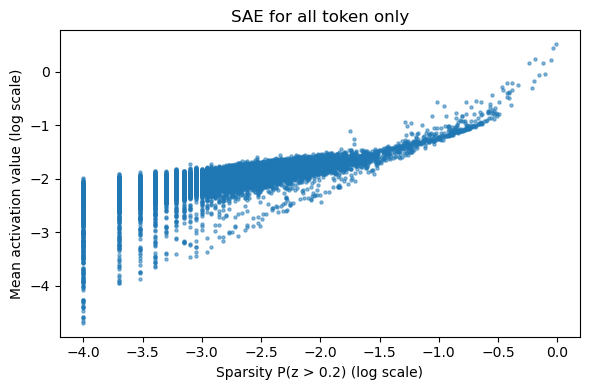

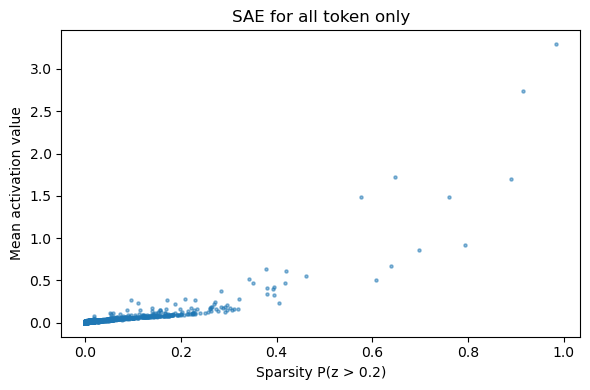

In [ ]:
# SAE latent sparsity and activation summaries
@torch.no_grad()
def summarize_sae_latents(sae, tokens, batch_size=SAE_BATCH_SIZE, thresholds=(0.0, 1e-3, 1e-2, 0.1, SAE_ACTIVE_THRESHOLD)):
    sae.eval()
    device = next(sae.parameters()).device
    total = 0
    sum_z = torch.zeros(sae.hidden_dim)
    max_z = torch.full((sae.hidden_dim,), -float('inf'))
    active = {float(th): torch.zeros(sae.hidden_dim) for th in thresholds}

    for start in range(0, tokens.shape[0], batch_size):
        xb = tokens[start:start + batch_size].float().to(device)
        z = sae.encode(xb).detach().cpu().float()
        sum_z += z.sum(dim=0)
        max_z = torch.maximum(max_z, z.max(dim=0).values)
        for th in active:
            active[th] += (z > th).float().sum(dim=0)
        total += z.shape[0]

    out = {
        'mean_activation': sum_z / max(1, total),
        'max_activation': max_z,
        'num_tokens': total,
    }
    for th, counts in active.items():
        out[f'freq_gt_{th:g}'] = counts / max(1, total)
    return out


def plot_sae_latent_stats(stats, title=None, log_scale=True, eps=1e-12):
    sparsity = stats.get(f'freq_gt_{SAE_ACTIVE_THRESHOLD:g}')
    if sparsity is None:
        sparsity = stats['freq_gt_0.1'] if 'freq_gt_0.1' in stats else stats['mean_activation'].gt(0).float()
    mean_activation = stats['mean_activation']
    mask = torch.isfinite(sparsity) & torch.isfinite(mean_activation) & (sparsity > 0) & (mean_activation > 0)
    x = sparsity[mask].numpy()
    y = mean_activation[mask].numpy()
    if log_scale:
        x = np.log10(np.clip(x, eps, None))
        y = np.log10(np.clip(y, eps, None))
        x_label = f'Sparsity P(z > {SAE_ACTIVE_THRESHOLD:g}) (log scale)'
        y_label = 'Mean activation value (log scale)'
    else:
        x_label = f'Sparsity P(z > {SAE_ACTIVE_THRESHOLD:g})'
        y_label = 'Mean activation value'
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(x, y, s=5, alpha=0.5)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig

sae_latent_stats = summarize_sae_latents(trained_sae, sae_val_tokens)
sae_latent_stats_fig = plot_sae_latent_stats(sae_latent_stats, title=f'SAE for {TOKEN_SCOPE} token only')
plt.show()
sae_latent_stats_linear_fig = plot_sae_latent_stats(sae_latent_stats, title=f'SAE for {TOKEN_SCOPE} token only', log_scale=False)
plt.show()


# 3. Class / Label Stats


In [ ]:
@torch.no_grad()
def sae_latent_label_stats(sae: nn.Module, tokens_norm, labels, batch_size=SAE_BATCH_SIZE, threshold=SAE_ACTIVE_THRESHOLD, device=DEVICE, eps=1e-12):
    sae.eval().to(device)
    labels = labels.detach().cpu().long()
    classes = sorted(labels.unique().tolist())
    class_to_pos = {int(c): i for i, c in enumerate(classes)}
    counts = torch.zeros(len(classes), sae.hidden_dim)
    totals = torch.zeros(len(classes))

    for start in range(0, tokens_norm.shape[0], batch_size):
        xb = tokens_norm[start:start + batch_size].float().to(device)
        yb = labels[start:start + batch_size]
        z = sae.encode(xb).detach().cpu()
        active = (z > threshold).float()
        for c in classes:
            mask = yb == int(c)
            if mask.any():
                pos = class_to_pos[int(c)]
                counts[pos] += active[mask].sum(dim=0)
                totals[pos] += mask.sum().item()

    freq = counts / totals.clamp_min(1).unsqueeze(1)
    specificity = freq.max(dim=0).values - freq.mean(dim=0)
    top_class = freq.argmax(dim=0)
    return {'classes': classes, 'freq': freq, 'specificity': specificity, 'top_class': top_class}

sae_label_stats = sae_latent_label_stats(trained_sae, sae_val_tokens, sae_val_labels)
label_specificity_values, label_specificity_latents = torch.topk(
    sae_label_stats['specificity'],
    k=min(20, sae_label_stats['specificity'].numel()),
)
list(zip(label_specificity_latents.tolist(), label_specificity_values.tolist()))


[(18, 0.0),
 (10, 0.0),
 (4, 0.0),
 (16, 0.0),
 (12, 0.0),
 (8, 0.0),
 (19, 0.0),
 (1, 0.0),
 (11, 0.0),
 (5, 0.0),
 (15, 0.0),
 (13, 0.0),
 (7, 0.0),
 (17, 0.0),
 (3, 0.0),
 (9, 0.0),
 (0, 0.0),
 (2, 0.0),
 (6, 0.0),
 (14, 0.0)]

# 4. Reconstruction / Downstream Check


In [ ]:
@torch.no_grad()
def evaluate_sae_reconstruction_full(sae: VanillaL1SAE, tokens: torch.Tensor, batch_size=SAE_BATCH_SIZE, threshold=SAE_ACTIVE_THRESHOLD, eps=1e-8):
    sae.eval()
    device = sae.W_dec.device
    total_rows = total_elements = 0
    sse = norm_sse = cosine_sum = l0_sum = l1_sum = 0.0
    active_counts = torch.zeros(sae.hidden_dim)
    token_sum = torch.zeros(tokens.shape[1])
    token_sq_sum = torch.zeros(tokens.shape[1])

    for start in range(0, tokens.shape[0], batch_size):
        xb_cpu = tokens[start:start + batch_size].float()
        xb = xb_cpu.to(device)
        x_hat, z = sae(xb)
        x_hat_cpu = x_hat.detach().cpu().float()
        z_cpu = z.detach().cpu().float()
        err = xb_cpu - x_hat_cpu
        sse += float(err.pow(2).sum().item())
        norm_sse += float((err.pow(2).sum(dim=-1) / xb_cpu.pow(2).sum(dim=-1).clamp_min(eps)).sum().item())
        cosine_sum += float(F.cosine_similarity(xb_cpu, x_hat_cpu, dim=-1).sum().item())
        l0_sum += float((z_cpu > threshold).float().sum(dim=-1).sum().item())
        l1_sum += float(z_cpu.abs().sum(dim=-1).sum().item())
        active_counts += (z_cpu > threshold).float().sum(dim=0)
        token_sum += xb_cpu.sum(dim=0)
        token_sq_sum += xb_cpu.pow(2).sum(dim=0)
        total_rows += xb_cpu.shape[0]
        total_elements += xb_cpu.numel()

    mean = token_sum / max(1, total_rows)
    ss_tot = float((token_sq_sum - total_rows * mean.pow(2)).sum().item())
    mse = sse / max(1, total_elements)
    return {
        'mse': mse,
        'token_nmse': norm_sse / max(1, total_rows),
        'r2': 1.0 - sse / max(ss_tot, eps),
        'cosine': cosine_sum / max(1, total_rows),
        'mean_l0': l0_sum / max(1, total_rows),
        'mean_l1': l1_sum / max(1, total_rows),
        'active_ratio': (l0_sum / max(1, total_rows)) / sae.hidden_dim,
        'dead_latent_frac': float((active_counts == 0).float().mean().item()),
    }


IMAGENETTE_TO_IMAGENET_IDX = torch.tensor([0, 217, 482, 491, 497, 566, 569, 571, 574, 701], dtype=torch.long)
DOWNSTREAM_MAX_BATCHES = None


@torch.no_grad()
def reconstruct_tokens_for_model_space(sae, tokens, token_stats):
    device = sae.W_dec.device
    flat_tokens = tokens.reshape(-1, tokens.shape[-1]).float().to(device)
    mean = token_stats['mean'].to(device=device, dtype=flat_tokens.dtype)
    std = token_stats['std'].to(device=device, dtype=flat_tokens.dtype)
    flat_tokens_norm = (flat_tokens - mean) / std
    flat_recon_norm, _ = sae(flat_tokens_norm)
    flat_recon = flat_recon_norm * std + mean
    return flat_recon.reshape_as(tokens).to(dtype=tokens.dtype)


@torch.no_grad()
def replace_block_output_with_sae_reconstruction(output, sae, token_stats, token_scope=TOKEN_SCOPE):
    if isinstance(output, (tuple, list)):
        output = output[0]
    recon = output.detach().clone()
    if token_scope == 'cls':
        recon[:, :1, :] = reconstruct_tokens_for_model_space(sae, output[:, :1, :], token_stats)
    elif token_scope == 'patch':
        recon[:, 1:, :] = reconstruct_tokens_for_model_space(sae, output[:, 1:, :], token_stats)
    elif token_scope in {'all', 'clspatch'}:
        recon = reconstruct_tokens_for_model_space(sae, output, token_stats)
    else:
        raise ValueError("TOKEN_SCOPE must be one of: 'cls', 'patch', 'all'.")
    return recon

reconstruction_full_metrics = evaluate_sae_reconstruction_full(trained_sae, sae_val_tokens)
reconstruction_full_metrics


{'mse': 0.011782228724161783,
 'token_nmse': 0.011858052110671997,
 'r2': 0.9841088257266781,
 'cosine': 0.9944173217773438,
 'mean_l0': 114.1313,
 'mean_l1': 283.269046875,
 'active_ratio': 0.0023220072428385414,
 'dead_latent_frac': 0.5853474736213684}

# 5. SAE Top Activating Samples / Patches


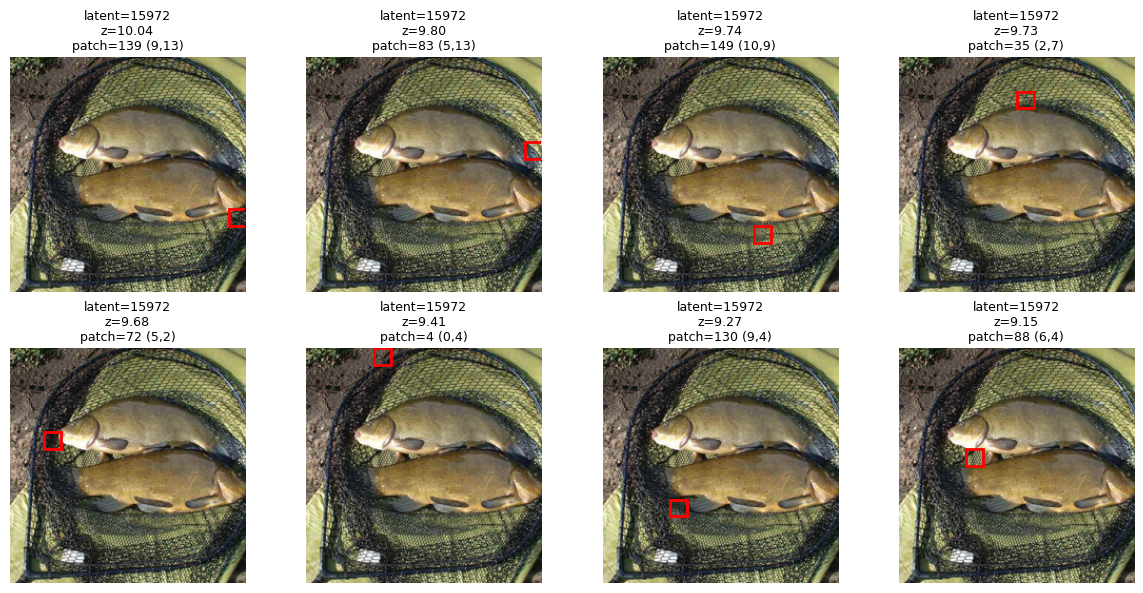

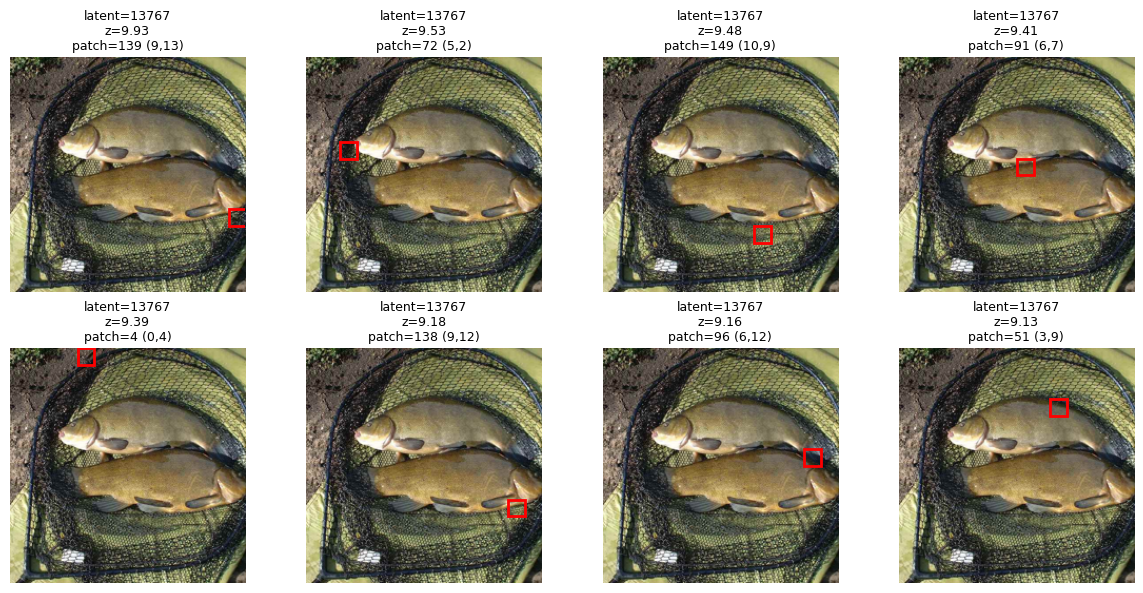

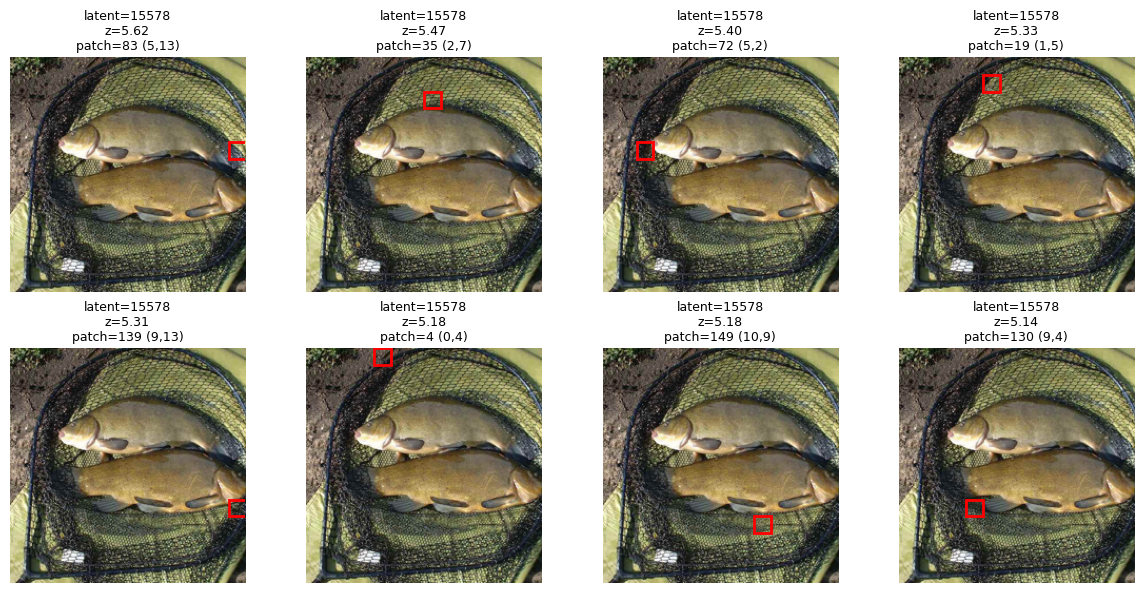

{15972: [{'image_pos': 33,
   'token_type': 'patch',
   'patch_id': 139,
   'patch_y': 9,
   'patch_x': 13,
   'latent_id': 15972,
   'activation': 10.044869422912598,
   'label': 0},
  {'image_pos': 33,
   'token_type': 'patch',
   'patch_id': 83,
   'patch_y': 5,
   'patch_x': 13,
   'latent_id': 15972,
   'activation': 9.804224014282227,
   'label': 0},
  {'image_pos': 33,
   'token_type': 'patch',
   'patch_id': 149,
   'patch_y': 10,
   'patch_x': 9,
   'latent_id': 15972,
   'activation': 9.74135684967041,
   'label': 0},
  {'image_pos': 33,
   'token_type': 'patch',
   'patch_id': 35,
   'patch_y': 2,
   'patch_x': 7,
   'latent_id': 15972,
   'activation': 9.72658634185791,
   'label': 0},
  {'image_pos': 33,
   'token_type': 'patch',
   'patch_id': 72,
   'patch_y': 5,
   'patch_x': 2,
   'latent_id': 15972,
   'activation': 9.682750701904297,
   'label': 0},
  {'image_pos': 33,
   'token_type': 'patch',
   'patch_id': 4,
   'patch_y': 0,
   'patch_x': 4,
   'latent_id': 15972

In [ ]:
# SAE top activating samples / patches
from matplotlib.patches import Rectangle

LATENT_IDS_TO_SHOW = top_freq_latents[:3].tolist() if 'top_freq_latents' in globals() else [0, 1, 2]
TOP_K = 8


@torch.no_grad()
def top_latent_tokens(sae, tokens, latent_id, top_k=8, batch_size=SAE_BATCH_SIZE):
    sae.eval()
    device = sae.W_dec.device
    values = []
    indices = []
    for start in range(0, tokens.shape[0], batch_size):
        xb = tokens[start:start + batch_size].float().to(device)
        z_i = sae.encode(xb)[:, int(latent_id)].detach().cpu()
        k = min(top_k, z_i.numel())
        batch_values, batch_indices = torch.topk(z_i, k=k)
        values.append(batch_values)
        indices.append(batch_indices + start)
    values = torch.cat(values)
    indices = torch.cat(indices)
    k = min(top_k, values.numel())
    top_values, order = torch.topk(values, k=k)
    return top_values, indices[order]


def token_index_to_image_patch(token_idx, token_scope=TOKEN_SCOPE, grid=14):
    token_idx = int(token_idx)
    patch_count = grid * grid
    if token_scope == 'patch':
        image_pos = token_idx // patch_count
        patch_id = token_idx % patch_count
        token_type = 'patch'
    elif token_scope in {'all', 'clspatch'}:
        tokens_per_image = patch_count + 1
        image_pos = token_idx // tokens_per_image
        local_idx = token_idx % tokens_per_image
        if local_idx == 0:
            return {'image_pos': image_pos, 'token_type': 'cls', 'patch_id': None, 'patch_y': None, 'patch_x': None}
        patch_id = local_idx - 1
        token_type = 'patch'
    elif token_scope == 'cls':
        return {'image_pos': token_idx, 'token_type': 'cls', 'patch_id': None, 'patch_y': None, 'patch_x': None}
    else:
        raise ValueError("TOKEN_SCOPE must be one of: 'cls', 'patch', 'all'.")
    return {'image_pos': image_pos, 'token_type': token_type, 'patch_id': patch_id, 'patch_y': patch_id // grid, 'patch_x': patch_id % grid}


def model_tensor_to_image(x, data_config=data_config):
    mean = torch.tensor(data_config['mean'], dtype=x.dtype).view(3, 1, 1)
    std = torch.tensor(data_config['std'], dtype=x.dtype).view(3, 1, 1)
    return (x.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def show_top_latent_samples(sae, tokens, dataset, latent_id, top_k=8, token_scope=TOKEN_SCOPE, grid=14):
    values, token_indices = top_latent_tokens(sae, tokens, latent_id, top_k=top_k)
    rows = math.ceil(len(token_indices) / 4)
    fig, axes = plt.subplots(rows, 4, figsize=(12, 3 * rows))
    axes = np.asarray(axes).reshape(-1)
    records = []
    for ax, value, token_idx in zip(axes, values, token_indices):
        meta = token_index_to_image_patch(int(token_idx), token_scope=token_scope, grid=grid)
        image_tensor, label = dataset[int(meta['image_pos'])]
        ax.imshow(model_tensor_to_image(image_tensor))
        title = f"latent={int(latent_id)}\nz={float(value):.2f}"
        if meta['token_type'] == 'patch':
            patch_h = image_tensor.shape[-2] / grid
            patch_w = image_tensor.shape[-1] / grid
            rect = Rectangle((meta['patch_x'] * patch_w, meta['patch_y'] * patch_h), patch_w, patch_h, fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            title += f"\npatch={meta['patch_id']} ({meta['patch_y']},{meta['patch_x']})"
        else:
            title += "\nCLS"
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        records.append({**meta, 'latent_id': int(latent_id), 'activation': float(value), 'label': int(label)})
    for ax in axes[len(token_indices):]:
        ax.axis('off')
    fig.tight_layout()
    return fig, records

top_latent_figs = []
top_latent_records_by_latent = {}
for latent_id in LATENT_IDS_TO_SHOW:
    fig, records = show_top_latent_samples(trained_sae, sae_val_tokens, test_ds, latent_id=int(latent_id), top_k=TOP_K)
    top_latent_figs.append(fig)
    top_latent_records_by_latent[int(latent_id)] = records
    plt.show()

top_latent_records_by_latent


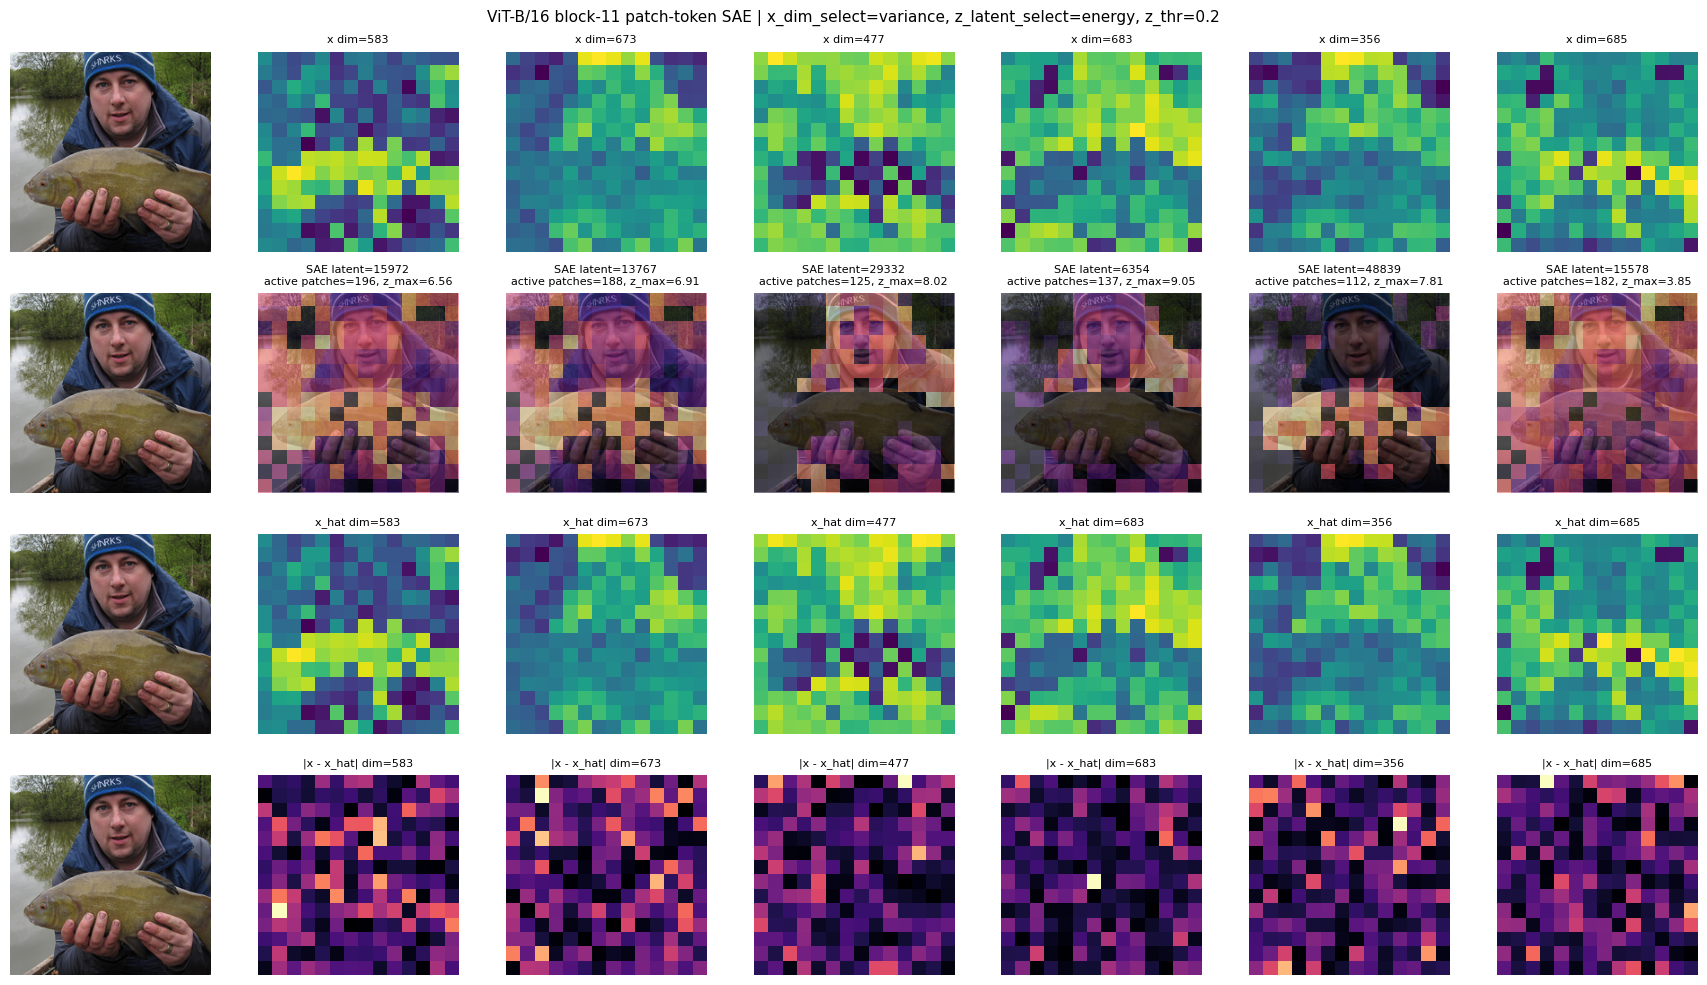

{'image_idx': 3,
 'x_channels': [583, 673, 477, 683, 356, 685],
 'z_latents': [15972, 13767, 29332, 6354, 48839, 15578]}

In [ ]:
@torch.no_grad()
def collect_sae_image_tensors(image_idx, model=vit_b, dataset=test_ds, sae=trained_sae, token_stats=sae_token_stats, target_block=TARGET_BLOCK, token_scope=TOKEN_SCOPE, device=DEVICE):
    image_tensor, label = dataset[int(image_idx)]
    captured = {}

    def hook(_module, _inputs, output):
        if isinstance(output, (tuple, list)):
            output = output[0]
        captured['block_output'] = output.detach().float().cpu()

    handle = model.blocks[target_block].register_forward_hook(hook)
    try:
        model.eval().to(device)
        _ = model(image_tensor.unsqueeze(0).to(device))
    finally:
        handle.remove()

    h = captured['block_output']
    if token_scope == 'patch':
        x_raw = h[:, 1:, :]
        patch_start = 0
    elif token_scope in {'all', 'clspatch'}:
        x_raw = h
        patch_start = 1
    else:
        raise ValueError('CLS token only has no 14x14 patch map.')

    x = normalize_tokens(x_raw.reshape(-1, x_raw.shape[-1]), token_stats).reshape(x_raw.shape)
    flat_x = x.reshape(-1, x.shape[-1]).float().to(device)
    sae.eval().to(device)
    flat_z = sae.encode(flat_x)
    flat_x_hat = sae.decode(flat_z)
    z = flat_z.detach().cpu().reshape(x.shape[0], x.shape[1], -1)
    x_hat = flat_x_hat.detach().cpu().reshape(x.shape)

    return {'image': image_tensor, 'label': label, 'x': x[0, patch_start:, :], 'z': z[0, patch_start:, :], 'x_hat': x_hat[0, patch_start:, :]}


def _normalize_map(m, eps=1e-8):
    m = m.detach().float().cpu()
    m = m - m.min()
    return m / (m.max() + eps)


def _plot_overlay(ax, image_np, patch_map, grid=14, cmap='magma', alpha=0.55):
    patch_map = _normalize_map(patch_map).reshape(grid, grid)
    ax.imshow(image_np)
    ax.imshow(patch_map, cmap=cmap, alpha=alpha, extent=(0, image_np.shape[1], image_np.shape[0], 0), interpolation='nearest')
    ax.axis('off')


def select_x_channels(x, n_channels=6, mode='variance'):
    if mode == 'variance':
        score = x.var(dim=0)
    elif mode == 'mean_abs':
        score = x.abs().mean(dim=0)
    else:
        raise ValueError(f'Unknown x channel selection mode: {mode}')
    return score.topk(n_channels).indices.tolist()


def select_z_latents(z, n_latents=6, mode='energy', active_threshold=SAE_ACTIVE_THRESHOLD):
    if mode == 'peak_sparse':
        peak = z.max(dim=0).values
        active_count = (z > active_threshold).sum(dim=0)
        score = peak / active_count.clamp_min(1)
    elif mode == 'energy':
        score = z.pow(2).mean(dim=0)
    elif mode == 'mean':
        score = z.mean(dim=0)
    else:
        raise ValueError(f'Unknown z latent selection mode: {mode}')
    return score.topk(n_latents).indices.tolist()


def plot_sae_channel_maps(image_idx=3, n_channels=6, x_select_mode='variance', z_select_mode='energy', active_threshold=SAE_ACTIVE_THRESHOLD, grid=14):
    sample = collect_sae_image_tensors(image_idx)
    image_np = model_tensor_to_image(sample['image'])
    x = sample['x']
    z = sample['z']
    x_hat = sample['x_hat']
    err = (x - x_hat).abs()
    x_channels = select_x_channels(x, n_channels=n_channels, mode=x_select_mode)
    z_latents = select_z_latents(z, n_latents=n_channels, mode=z_select_mode, active_threshold=active_threshold)

    fig, axes = plt.subplots(4, n_channels + 1, figsize=(2.5 * (n_channels + 1), 10))
    axes[0, 0].imshow(image_np)
    axes[0, 0].set_ylabel('ViT-B x', fontsize=10)
    axes[1, 0].imshow(image_np)
    axes[1, 0].set_ylabel('SAE z', fontsize=10)
    axes[2, 0].imshow(image_np)
    axes[2, 0].set_ylabel('SAE x_hat', fontsize=10)
    axes[3, 0].imshow(image_np)
    axes[3, 0].set_ylabel('|x - x_hat|', fontsize=10)
    for ax in axes[:, 0]:
        ax.axis('off')

    for j, ch in enumerate(x_channels):
        axes[0, j + 1].imshow(x[:, ch].reshape(grid, grid), cmap='viridis')
        axes[0, j + 1].set_title(f'x dim={ch}', fontsize=8)
        axes[0, j + 1].axis('off')
        axes[2, j + 1].imshow(x_hat[:, ch].reshape(grid, grid), cmap='viridis')
        axes[2, j + 1].set_title(f'x_hat dim={ch}', fontsize=8)
        axes[2, j + 1].axis('off')
        axes[3, j + 1].imshow(err[:, ch].reshape(grid, grid), cmap='magma')
        axes[3, j + 1].set_title(f'|x - x_hat| dim={ch}', fontsize=8)
        axes[3, j + 1].axis('off')

    for j, latent_id in enumerate(z_latents):
        z_map = z[:, latent_id].reshape(grid, grid)
        _plot_overlay(axes[1, j + 1], image_np, z_map, grid=grid)
        active_count = int((z[:, latent_id] > active_threshold).sum().item())
        peak = z[:, latent_id].max().item()
        axes[1, j + 1].set_title(f'SAE latent={latent_id}\nactive patches={active_count}, z_max={peak:.2f}', fontsize=8)

    fig.suptitle(f'ViT-B/16 block-{TARGET_BLOCK} patch-token SAE | x_dim_select={x_select_mode}, z_latent_select={z_select_mode}, z_thr={active_threshold}', fontsize=11)
    fig.tight_layout()
    return fig, {'image_idx': image_idx, 'x_channels': x_channels, 'z_latents': z_latents}

fig, info = plot_sae_channel_maps(image_idx=3, n_channels=6, x_select_mode='variance', z_select_mode='energy')
plt.show()
info


# 5. Intervention


ranking perturbation-sensitive latents:   0%|          | 0/12 [00:00<?, ?it/s]


[grayscale] top 10 latents
rank latent score_delta freq mean_z peak_delta
   1  15972 1.231459 0.990646 3.440277 5.554368
   2  13767 1.189442 0.931122 2.787144 6.587243
   3  48839 0.773066 0.627976 1.596193 7.001025
   4  15578 0.705434 0.902211 1.776997 3.733845
   5   6627 0.589910 0.709609 1.312536 4.309614
   6  29332 0.521124 0.519133 1.359075 6.795677
   7  37048 0.499336 0.588435 1.212690 8.646545
   8  33741 0.418083 0.810374 0.894527 2.182575
   9   5522 0.409031 0.522534 0.960956 7.909506
  10  23396 0.400244 0.655187 0.807231 3.016761

[blur] top 10 latents
rank latent score_delta freq mean_z peak_delta
   1  13767 1.249688 0.931122 2.787144 7.859745
   2  15972 1.207852 0.990646 3.440277 6.333625
   3  37048 0.908707 0.588435 1.212690 9.410781
   4   6627 0.870513 0.709609 1.312536 4.490897
   5  48839 0.851767 0.627976 1.596193 9.145414
   6  15578 0.771730 0.902211 1.776997 3.876084
   7   5522 0.753233 0.522534 0.960956 8.138712
   8  23396 0.660966 0.655187 0.807231 

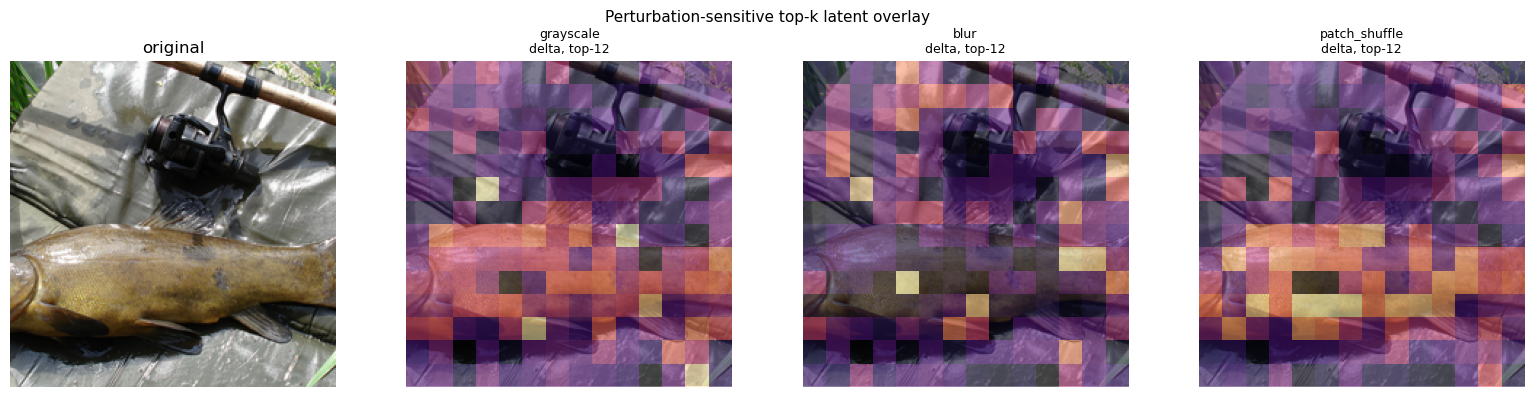

{'grayscale': [15972, 13767, 48839, 15578, 6627, 29332, 37048, 33741, 5522, 23396, 21669, 29428], 'blur': [13767, 15972, 37048, 6627, 48839, 15578, 5522, 23396, 29332, 11076, 21669, 33741], 'patch_shuffle': [15972, 13767, 48839, 15578, 29332, 6627, 37048, 5522, 33741, 23396, 21669, 11478]}


In [ ]:
# Perturbation-sensitive SAE latent ranking and top-k overlays
import gc

PERTURBATION_KINDS = ("grayscale", "blur", "patch_shuffle")
PERTURBATION_TOP_K = 20
PERTURBATION_OVERLAY_TOP_K = 12
PERTURBATION_ANALYSIS_INDICES = list(range(min(12, len(test_ds))))
PERTURBATION_BATCH_SIZE = 1
PERTURBATION_ENCODE_CHUNK_SIZE = 256
PERTURBATION_BLUR_KERNEL = 7
PERTURBATION_SHUFFLE_SEED = 0


def model_tensor_to_unit_tensor(x, data_config=data_config):
    mean = torch.tensor(data_config['mean'], dtype=x.dtype, device=x.device).view(3, 1, 1)
    std = torch.tensor(data_config['std'], dtype=x.dtype, device=x.device).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)


def unit_tensor_to_model_tensor(x, data_config=data_config):
    mean = torch.tensor(data_config['mean'], dtype=x.dtype, device=x.device).view(3, 1, 1)
    std = torch.tensor(data_config['std'], dtype=x.dtype, device=x.device).view(3, 1, 1)
    return (x.clamp(0, 1) - mean) / std


def apply_image_perturbation(image_tensor, kind, image_idx=0, grid=14, blur_kernel=PERTURBATION_BLUR_KERNEL, seed=PERTURBATION_SHUFFLE_SEED):
    unit = model_tensor_to_unit_tensor(image_tensor)
    if kind == 'identity':
        perturbed = unit
    elif kind == 'grayscale':
        gray = unit.mean(dim=0, keepdim=True)
        perturbed = gray.repeat(3, 1, 1)
    elif kind == 'blur':
        k = int(blur_kernel)
        if k % 2 == 0:
            k += 1
        perturbed = F.avg_pool2d(unit.unsqueeze(0), kernel_size=k, stride=1, padding=k // 2).squeeze(0)
    elif kind == 'patch_shuffle':
        c, h, w = unit.shape
        patch_h = h // grid
        patch_w = w // grid
        patches = unit[:, :patch_h * grid, :patch_w * grid].reshape(c, grid, patch_h, grid, patch_w).permute(1, 3, 0, 2, 4).reshape(grid * grid, c, patch_h, patch_w)
        g = torch.Generator().manual_seed(int(seed) + int(image_idx))
        patches = patches[torch.randperm(patches.shape[0], generator=g)]
        perturbed = patches.reshape(grid, grid, c, patch_h, patch_w).permute(2, 0, 3, 1, 4).reshape(c, patch_h * grid, patch_w * grid)
        if perturbed.shape[-2:] != unit.shape[-2:]:
            canvas = unit.clone()
            canvas[:, :perturbed.shape[-2], :perturbed.shape[-1]] = perturbed
            perturbed = canvas
    else:
        raise ValueError(f'Unknown perturbation kind: {kind}')
    return unit_tensor_to_model_tensor(perturbed)


@torch.no_grad()
def collect_patch_latents_for_batch(images, model=vit_b, sae=trained_sae, token_stats=sae_token_stats, target_block=TARGET_BLOCK, token_scope=TOKEN_SCOPE, device=DEVICE, encode_chunk_size=PERTURBATION_ENCODE_CHUNK_SIZE):
    captured = {}

    def hook(_module, _inputs, output):
        if isinstance(output, (tuple, list)):
            output = output[0]
        captured['block_output'] = output.detach().float().cpu()

    handle = model.blocks[target_block].register_forward_hook(hook)
    try:
        model.eval().to(device)
        _ = model(images.to(device))
    finally:
        handle.remove()

    h = captured['block_output']
    if token_scope == 'patch':
        patch_tokens = h[:, 1:, :]
    elif token_scope in {'all', 'clspatch'}:
        patch_tokens = h[:, 1:, :]
    else:
        raise ValueError("Patch-grid latent maps require TOKEN_SCOPE='patch' or 'all'.")

    flat_tokens = patch_tokens.reshape(-1, patch_tokens.shape[-1]).float()
    mean = token_stats['mean'].float()
    std = token_stats['std'].float()
    z_chunks = []
    sae.eval().to(device)
    for start in range(0, flat_tokens.shape[0], encode_chunk_size):
        chunk = flat_tokens[start:start + encode_chunk_size]
        chunk = normalize_tokens_inplace(chunk, {'mean': mean, 'std': std}).to(device)
        z_chunks.append(sae.encode(chunk).detach().cpu())
    z = torch.cat(z_chunks, dim=0)
    return z.reshape(patch_tokens.shape[0], patch_tokens.shape[1], -1)


def _ranking_records(score, frequency, mean_activation, peak_delta, top_k=PERTURBATION_TOP_K):
    k = min(top_k, score.numel())
    top_scores, top_ids = torch.topk(score, k=k)
    records = []
    for rank, (latent_id, value) in enumerate(zip(top_ids.tolist(), top_scores.tolist()), start=1):
        records.append({
            'rank': rank,
            'latent_id': int(latent_id),
            'score_delta': float(value),
            'frequency': float(frequency[latent_id].item()),
            'mean_activation': float(mean_activation[latent_id].item()),
            'peak_abs_delta': float(peak_delta[latent_id].item()),
        })
    return {'latent_ids': top_ids.tolist(), 'records': records}


@torch.no_grad()
def rank_perturbation_sensitive_latents(image_indices=None, kinds=PERTURBATION_KINDS, batch_size=PERTURBATION_BATCH_SIZE, top_k=PERTURBATION_TOP_K):
    if image_indices is None:
        image_indices = PERTURBATION_ANALYSIS_INDICES
    accum = {kind: None for kind in kinds}
    count = 0

    iterator = list(range(0, len(image_indices), batch_size))
    for start in tqdm(iterator, total=math.ceil(len(image_indices) / batch_size), desc='ranking perturbation-sensitive latents'):
        idxs = image_indices[start:start + batch_size]
        images = torch.stack([test_ds[int(i)][0] for i in idxs], dim=0)
        z_orig = collect_patch_latents_for_batch(images)
        for kind in kinds:
            perturbed = torch.stack([apply_image_perturbation(test_ds[int(i)][0], kind, image_idx=int(i)) for i in idxs], dim=0)
            z_perturbed = collect_patch_latents_for_batch(perturbed)
            delta = (z_perturbed - z_orig).abs()
            delta_sum = delta.sum(dim=(0, 1))
            peak_delta = delta.amax(dim=(0, 1))
            active = (z_orig > SAE_ACTIVE_THRESHOLD).float()
            freq_sum = active.sum(dim=(0, 1))
            mean_sum = z_orig.sum(dim=(0, 1))
            if accum[kind] is None:
                accum[kind] = {'delta_sum': delta_sum, 'peak_delta': peak_delta, 'freq_sum': freq_sum, 'mean_sum': mean_sum}
            else:
                accum[kind]['delta_sum'] += delta_sum
                accum[kind]['peak_delta'] = torch.maximum(accum[kind]['peak_delta'], peak_delta)
                accum[kind]['freq_sum'] += freq_sum
                accum[kind]['mean_sum'] += mean_sum
            del z_perturbed, delta, perturbed
        count += z_orig.shape[0] * z_orig.shape[1]
        del z_orig, images
        gc.collect()

    results = {}
    for kind in kinds:
        item = accum[kind]
        score = item['delta_sum'] / max(1, count)
        frequency = item['freq_sum'] / max(1, count)
        mean_activation = item['mean_sum'] / max(1, count)
        results[kind] = _ranking_records(score, frequency, mean_activation, item['peak_delta'], top_k=top_k)
    return results


def print_perturbation_rankings(rankings, top_n=10):
    for kind, result in rankings.items():
        print(f"\n[{kind}] top {min(top_n, len(result['records']))} latents")
        print('rank latent score_delta freq mean_z peak_delta')
        for row in result['records'][:top_n]:
            print(f"{row['rank']:>4} {row['latent_id']:>6} {row['score_delta']:.6f} {row['frequency']:.6f} {row['mean_activation']:.6f} {row['peak_abs_delta']:.6f}")


def plot_perturbation_topk_overlays(image_idx=0, rankings=None, top_k=PERTURBATION_OVERLAY_TOP_K, map_mode='delta'):
    if rankings is None:
        rankings = perturbation_latent_rankings
    image = test_ds[int(image_idx)][0]
    original = image.unsqueeze(0)
    z_orig = collect_patch_latents_for_batch(original)
    image_np = model_tensor_to_image(image)
    fig, axes = plt.subplots(1, len(PERTURBATION_KINDS) + 1, figsize=(4 * (len(PERTURBATION_KINDS) + 1), 4))
    axes[0].imshow(image_np)
    axes[0].set_title('original')
    axes[0].axis('off')
    latent_ids_by_kind = {}
    for ax, kind in zip(axes[1:], PERTURBATION_KINDS):
        ids = rankings[kind]['latent_ids'][:top_k]
        latent_ids_by_kind[kind] = [int(x) for x in ids]
        perturbed = apply_image_perturbation(image, kind, image_idx=int(image_idx)).unsqueeze(0)
        z_perturbed = collect_patch_latents_for_batch(perturbed)
        if map_mode == 'delta':
            patch_map = (z_perturbed[:, :, ids] - z_orig[:, :, ids]).abs().mean(dim=-1)[0]
        else:
            patch_map = z_perturbed[:, :, ids].mean(dim=-1)[0]
        _plot_overlay(ax, image_np, patch_map)
        ax.set_title(f"{kind}\n{map_mode}, top-{len(ids)}", fontsize=9)
    fig.suptitle('Perturbation-sensitive top-k latent overlay', fontsize=11)
    fig.tight_layout()
    return fig, {'latent_ids': latent_ids_by_kind}

perturbation_latent_rankings = rank_perturbation_sensitive_latents(image_indices=PERTURBATION_ANALYSIS_INDICES)
print_perturbation_rankings(perturbation_latent_rankings, top_n=10)
fig, perturbation_overlay_info = plot_perturbation_topk_overlays(image_idx=0, rankings=perturbation_latent_rankings)
plt.show()
print(perturbation_overlay_info['latent_ids'])


[Intervention latent specs]
color_latents/cue_latents [15972, 13767, 48839, 15578, 6627, 29332, 37048, 33741, 5522, 23396, 21669, 29428]
color_latents/matched_frequency_magnitude [11478, 37850, 26090, 6354, 44058, 27256, 12324, 30236, 3230, 17571, 42888, 5309]
color_latents/random_0 [36128, 28510, 16199, 39490, 29346, 17263, 31739, 22070, 11418, 46754, 40384, 38692]
color_latents/random_1 [4080, 22289, 19562, 33749, 42168, 41471, 31201, 16015, 19467, 11399, 46093, 44396]
color_latents/random_2 [30799, 32696, 34929, 8422, 43346, 11926, 46699, 1877, 30026, 12531, 23213, 14427]
texture_latents/cue_latents [13767, 15972, 37048, 6627, 48839, 15578, 5522, 23396, 29332, 11076, 21669, 33741]
texture_latents/matched_frequency_magnitude [11478, 37850, 29428, 26090, 6354, 44058, 27256, 12324, 30236, 3230, 17571, 42888]
texture_latents/random_0 [35675, 35294, 44500, 29074, 26061, 47100, 9289, 30310, 16241, 6391, 44329, 17842]
texture_latents/random_1 [9291, 4834, 26336, 32028, 12497, 34663, 32700,

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

...

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

latent intervention curve [all]:   0%|          | 0/12 [00:00<?, ?it/s]

name alpha metric acc_drop ce_delta logit_l1
color_latents/cue_latents 0.00 4.1463058473e-01 0.0000 2.297391 1.9784645488e-01
color_latents/cue_latents 0.25 2.2596201766e-01 0.0000 1.431716 1.5324479466e-01
color_latents/cue_latents 0.50 8.3412860210e-02 0.0000 0.809646 1.1308963411e-01
color_latents/cue_latents 0.75 1.5205147987e-02 0.0000 0.450587 8.2077848415e-02
color_latents/cue_latents 1.00 2.9652798718e-03 0.0000 0.275126 7.0402046666e-02
color_latents/cue_latents 1.25 1.2677247481e-02 0.0000 0.191972 8.4550726538e-02
color_latents/cue_latents 1.50 2.9230309495e-02 0.0000 0.148513 1.1195343422e-01
color_latents/matched_frequency_magnitude 0.00 3.0004021640e-03 0.0000 0.303301 7.2773161034e-02
color_latents/matched_frequency_magnitude 0.25 2.9036494622e-03 0.0000 0.295889 7.1775682891e-02
color_latents/matched_frequency_magnitude 0.50 2.8679196706e-03 0.0000 0.288730 7.1041353978e-02
color_latents/matched_frequency_magnitude 0.75 2.8896043514e-03 0.0000 0.281812 7.0585087252e-02


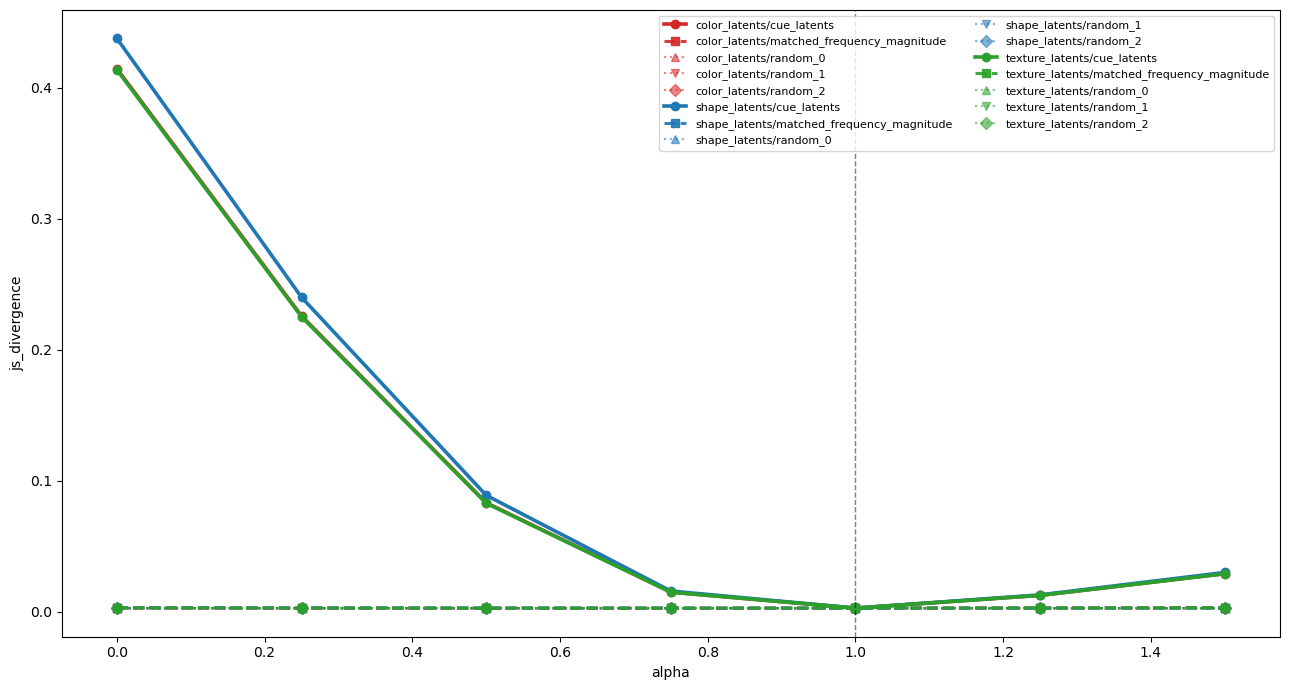

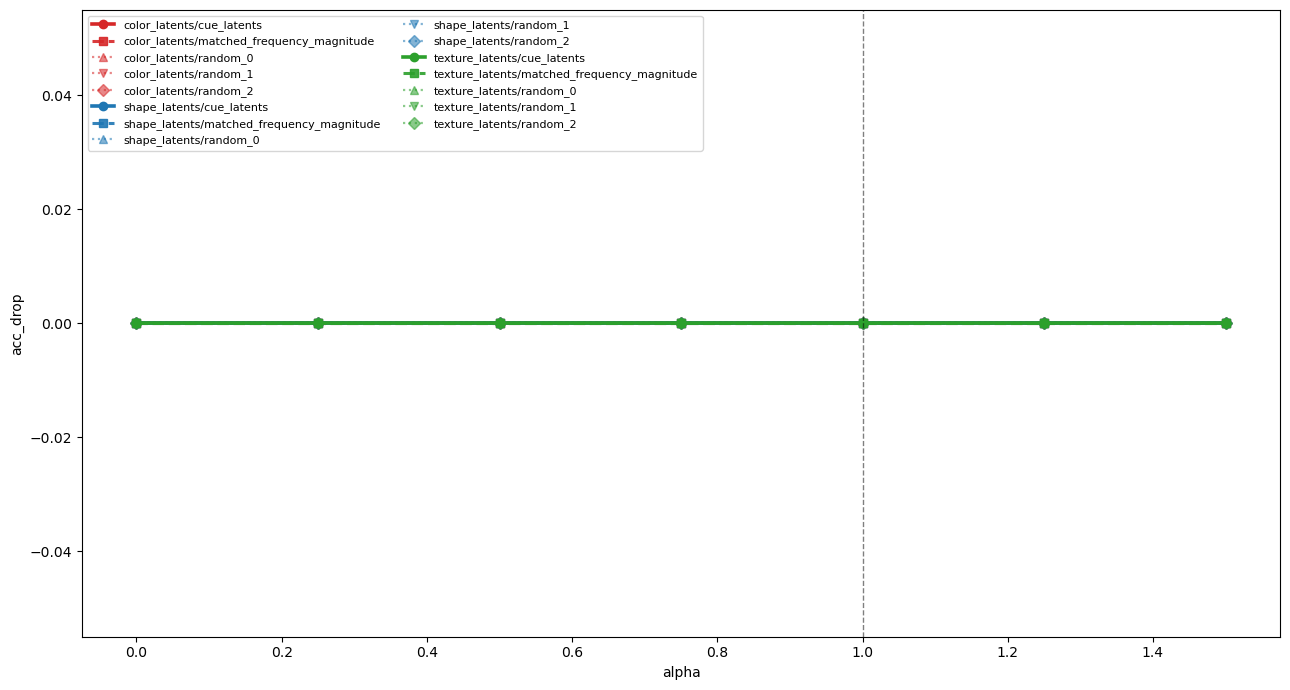

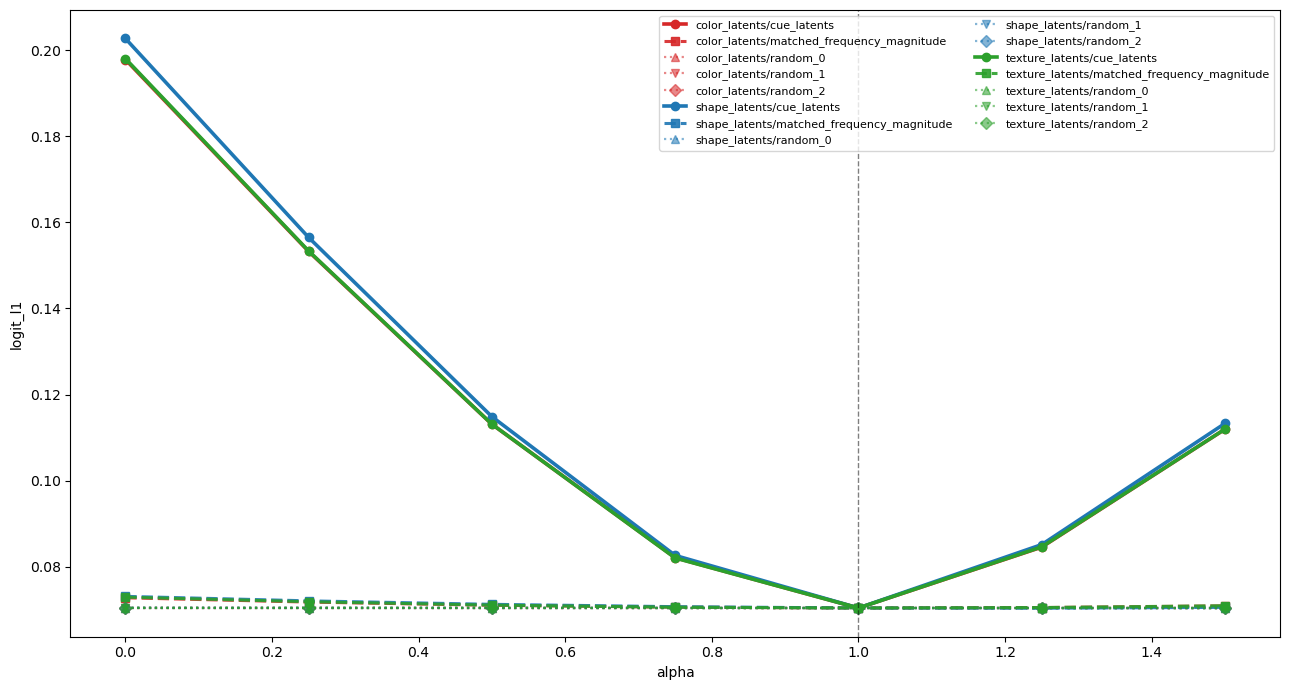

In [ ]:
# Latent intervention curves with matched and random baselines
# Revised full version

INTERVENTION_TOP_K = 12
INTERVENTION_RANDOM_TRIALS = 3
INTERVENTION_RANDOM_SEED = 0
INTERVENTION_ALPHA_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
INTERVENTION_BATCH_SIZE = 1
INTERVENTION_SAE_CHUNK_SIZE = 128
INTERVENTION_MAX_BATCHES = None
INTERVENTION_EVAL_INDICES = PERTURBATION_ANALYSIS_INDICES
INTERVENTION_TOKEN_SCOPE = "all"
INTERVENTION_TARGET_BLOCK = TARGET_BLOCK
INTERVENTION_REMOVE_SHARED_CUE_LATENTS = False
INTERVENTION_SHARED_MIN_GROUPS = len(PERTURBATION_KINDS)

PERTURBATION_FAMILY_NAMES = {
    'grayscale': 'color_latents',
    'blur': 'texture_latents',
    'patch_shuffle': 'shape_latents',
}


def make_intervention_eval_loader(dataset=test_ds, indices=INTERVENTION_EVAL_INDICES, batch_size=INTERVENTION_BATCH_SIZE):
    subset = torch.utils.data.Subset(dataset, [int(idx) for idx in indices])
    return DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())


def _as_long_tensor(ids):
    if torch.is_tensor(ids):
        return ids.detach().long().cpu()
    return torch.tensor([int(x) for x in ids], dtype=torch.long)


def match_latents_by_frequency_and_magnitude(target_ids, pool_ids=None, k=None):
    target_ids = [int(x) for x in target_ids]
    if k is None:
        k = len(target_ids)
    if pool_ids is None:
        pool_ids = list(range(trained_sae.hidden_dim))
    blocked = set(target_ids)
    pool_ids = [int(x) for x in pool_ids if int(x) not in blocked]
    if not pool_ids:
        return []
    freq = sae_latent_frequency.float()
    mean_act = sae_latent_stats['mean_activation'].float() if 'sae_latent_stats' in globals() else torch.zeros_like(freq)
    target_freq = freq[target_ids].mean() if target_ids else torch.tensor(0.0)
    target_mag = mean_act[target_ids].mean() if target_ids else torch.tensor(0.0)
    pool = torch.tensor(pool_ids, dtype=torch.long)
    score = (freq[pool] - target_freq).abs() + (mean_act[pool] - target_mag).abs()
    order = torch.argsort(score)[:k]
    return pool[order].tolist()


def random_latents(k, exclude=(), seed=0):
    exclude = set(int(x) for x in exclude)
    candidates = [i for i in range(trained_sae.hidden_dim) if i not in exclude]
    g = torch.Generator().manual_seed(int(seed))
    perm = torch.randperm(len(candidates), generator=g)[:k]
    return [candidates[int(i)] for i in perm]


def build_intervention_latent_specs(rankings, top_k=INTERVENTION_TOP_K, random_trials=INTERVENTION_RANDOM_TRIALS):
    specs = {}
    for kind, result in rankings.items():
        family = PERTURBATION_FAMILY_NAMES.get(kind, f'{kind}_latents')
        cue = [int(x) for x in result['latent_ids'][:top_k]]
        specs[(family, 'cue_latents')] = cue
        specs[(family, 'matched_frequency_magnitude')] = match_latents_by_frequency_and_magnitude(cue, k=len(cue))
        for trial in range(random_trials):
            specs[(family, f'random_{trial}')] = random_latents(len(cue), exclude=cue, seed=INTERVENTION_RANDOM_SEED + trial + 1000 * len(specs))
    print('[Intervention latent specs]')
    for (family, baseline), ids in specs.items():
        print(f'{family}/{baseline}', ids)
    return specs


@torch.no_grad()
def reconstruct_tokens_with_latent_scaling(tokens, sae, token_stats, latent_ids, alpha, return_debug=False):
    output_device = tokens.device
    output_dtype = tokens.dtype
    sae_device = next(sae.parameters()).device
    flat_tokens = tokens.reshape(-1, tokens.shape[-1]).to(device=sae_device, dtype=torch.float32)
    out_chunks = []
    debug_chunks = []
    ids = _as_long_tensor(latent_ids).to(sae_device) if latent_ids else None

    for start in range(0, flat_tokens.shape[0], INTERVENTION_SAE_CHUNK_SIZE):
        chunk = flat_tokens[start:start + INTERVENTION_SAE_CHUNK_SIZE]
        mean = token_stats['mean'].to(device=sae_device, dtype=chunk.dtype)
        std = token_stats['std'].to(device=sae_device, dtype=chunk.dtype)
        chunk_norm = (chunk - mean) / std
        z = sae.encode(chunk_norm)
        if ids is not None and ids.numel() > 0:
            z[:, ids] = z[:, ids] * float(alpha)
        recon_norm = sae.decode(z)
        recon = recon_norm * std + mean
        out_chunks.append(recon.detach())
        if return_debug:
            debug_chunks.append(z.detach().cpu())

    recon_tokens = torch.cat(out_chunks, dim=0).reshape_as(tokens).to(device=output_device, dtype=output_dtype)
    if not return_debug:
        return recon_tokens
    z_all = torch.cat(debug_chunks, dim=0)
    return recon_tokens, {'z_mean_abs': z_all.abs().mean().item(), 'z_l0': (z_all > SAE_ACTIVE_THRESHOLD).float().sum(dim=1).mean().item()}


@torch.no_grad()
def run_model_with_latent_intervention(images, latent_ids, alpha, model=vit_b, sae=trained_sae, token_stats=sae_token_stats, target_block=INTERVENTION_TARGET_BLOCK, intervention_token_scope=INTERVENTION_TOKEN_SCOPE, device=DEVICE):
    device = torch.device(device)
    def hook(_module, _inputs, output):
        if isinstance(output, (tuple, list)):
            block_output = output[0]
        else:
            block_output = output
        edited = block_output.detach().clone()
        if intervention_token_scope == 'cls':
            edited[:, :1, :] = reconstruct_tokens_with_latent_scaling(block_output[:, :1, :], sae, token_stats, latent_ids, alpha)
        elif intervention_token_scope == 'patch':
            edited[:, 1:, :] = reconstruct_tokens_with_latent_scaling(block_output[:, 1:, :], sae, token_stats, latent_ids, alpha)
        elif intervention_token_scope in {'all', 'clspatch'}:
            edited = reconstruct_tokens_with_latent_scaling(block_output, sae, token_stats, latent_ids, alpha)
        else:
            raise ValueError(f'Unknown intervention_token_scope: {intervention_token_scope}')
        return edited

    model.eval().to(device)
    sae.eval().to(device)
    handle = model.blocks[target_block].register_forward_hook(hook)
    try:
        logits = model(images.to(device)).detach().cpu()
    finally:
        handle.remove()
    return logits


@torch.no_grad()
def evaluate_latent_intervention_curve(specs, loader=None, alphas=INTERVENTION_ALPHA_VALUES, max_batches=INTERVENTION_MAX_BATCHES, device=DEVICE):
    device = torch.device(device)
    if loader is None:
        loader = make_intervention_eval_loader()
    records = []
    vit_b.eval().to(device)
    for (family, baseline), latent_ids in specs.items():
        for alpha in alphas:
            js_sum = ce_sum = logit_l1_sum = acc_sum = clean_acc_sum = 0.0
            rows = 0
            for batch_idx, (images, labels) in enumerate(tqdm(loader, desc=f'latent intervention curve [{INTERVENTION_TOKEN_SCOPE}]', leave=False)):
                if max_batches is not None and batch_idx >= int(max_batches):
                    break
                images = images.to(device)
                labels_cpu = labels.detach().cpu().long()
                clean_logits = vit_b(images).detach().cpu()
                int_logits = run_model_with_latent_intervention(images, latent_ids, alpha, device=device)
                labels_imagenet = IMAGENETTE_TO_IMAGENET_IDX[labels_cpu]
                clean_pred = clean_logits.argmax(dim=1)
                int_pred = int_logits.argmax(dim=1)
                clean_acc = (clean_pred == labels_imagenet).float().mean().item()
                intervention_acc = (int_pred == labels_imagenet).float().mean().item()
                clean_logp = F.log_softmax(clean_logits, dim=1)
                int_logp = F.log_softmax(int_logits, dim=1)
                m = 0.5 * (clean_logp.exp() + int_logp.exp()).clamp_min(1e-12)
                js = 0.5 * (F.kl_div(clean_logp, m, reduction='batchmean') + F.kl_div(int_logp, m, reduction='batchmean'))
                ce = F.cross_entropy(int_logits, labels_imagenet)
                js_sum += float(js.item()) * images.shape[0]
                ce_sum += float(ce.item()) * images.shape[0]
                logit_l1_sum += float((int_logits - clean_logits).abs().mean(dim=1).sum().item())
                acc_sum += intervention_acc * images.shape[0]
                clean_acc_sum += clean_acc * images.shape[0]
                rows += images.shape[0]
            clean_acc = clean_acc_sum / max(1, rows)
            intervention_acc = acc_sum / max(1, rows)
            records.append({
                'family': family,
                'baseline': baseline,
                'name': f'{family}/{baseline}',
                'alpha': float(alpha),
                'js_divergence': js_sum / max(1, rows),
                'cross_entropy': ce_sum / max(1, rows),
                'logit_l1': logit_l1_sum / max(1, rows),
                'clean_acc': clean_acc,
                'intervention_acc': intervention_acc,
                'acc_delta': intervention_acc - clean_acc,
                'acc_drop': clean_acc - intervention_acc,
                'n': rows,
            })
    return records


def print_intervention_curve_summary(records, metric='js_divergence'):
    print('name alpha metric acc_drop ce_delta logit_l1')
    for row in records:
        print(f"{row['name']} {row['alpha']:.2f} {row[metric]:.10e} {row['acc_drop']:.4f} {row['cross_entropy']:.6f} {row['logit_l1']:.10e}")


def plot_intervention_curve(records, metric='js_divergence', figsize=(13, 7), logy=False):
    family_colors = {'color_latents': 'tab:red', 'texture_latents': 'tab:green', 'shape_latents': 'tab:blue'}
    baseline_styles = {'cue_latents': ('-', 'o', 2.6, 1.0), 'matched_frequency_magnitude': ('--', 's', 2.2, 0.9), 'random_0': (':', '^', 1.6, 0.55), 'random_1': (':', 'v', 1.6, 0.55), 'random_2': (':', 'D', 1.6, 0.55)}
    fig, ax = plt.subplots(figsize=figsize)
    names = sorted(set(row['name'] for row in records))
    for name in names:
        family, baseline = name.split('/', 1)
        subset = sorted([row for row in records if row['name'] == name], key=lambda r: r['alpha'])
        xs = [row['alpha'] for row in subset]
        ys = [row[metric] for row in subset]
        linestyle, marker, linewidth, alpha = baseline_styles.get(baseline, ('-', 'o', 1.5, 0.8))
        ax.plot(xs, ys, linestyle=linestyle, marker=marker, linewidth=linewidth, alpha=alpha, color=family_colors.get(family), label=name)
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel('alpha')
    ax.set_ylabel(metric)
    if logy:
        ax.set_yscale('log')
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig

intervention_latent_specs = build_intervention_latent_specs(perturbation_latent_rankings)
intervention_eval_loader = make_intervention_eval_loader()
intervention_curve_records = evaluate_latent_intervention_curve(intervention_latent_specs, loader=intervention_eval_loader, alphas=INTERVENTION_ALPHA_VALUES)
print_intervention_curve_summary(intervention_curve_records, metric='js_divergence')
js_curve_fig = plot_intervention_curve(intervention_curve_records, metric='js_divergence', figsize=(13, 7), logy=False)
plt.show()
acc_drop_curve_fig = plot_intervention_curve(intervention_curve_records, metric='acc_drop', figsize=(13, 7), logy=False)
plt.show()
logit_l1_curve_fig = plot_intervention_curve(intervention_curve_records, metric='logit_l1', figsize=(13, 7), logy=False)
plt.show()


In [ ]:
LAST_EPOCHS_TO_PRINT = 50

if 'sae_history' not in globals() or not sae_history:
    raise ValueError('sae_history is empty. Run the SAE training cell first.')

for row in sae_history[-LAST_EPOCHS_TO_PRINT:]:
    print(
        f"epoch {int(row['epoch']):03d} | "
        f"train_loss={row['train_loss']:.6f} "
        f"train_mse={row['train_mse']:.6f} "
        f"train_l1={row['train_l1']:.6f} "
        f"val_nmse={row['normalized_mse']:.6f} "
        f"val_l0={row['mean_l0']:.2f}"
    )


epoch 251 | train_loss=0.033081 train_mse=0.009710 train_l1=292.140332 val_nmse=0.011170 val_l0=113.64
epoch 252 | train_loss=0.033191 train_mse=0.009778 train_l1=292.658238 val_nmse=0.011695 val_l0=110.54
epoch 253 | train_loss=0.033287 train_mse=0.009824 train_l1=293.287670 val_nmse=0.011192 val_l0=111.49
epoch 254 | train_loss=0.032836 train_mse=0.009669 train_l1=289.590067 val_nmse=0.011429 val_l0=111.25
epoch 255 | train_loss=0.033103 train_mse=0.009723 train_l1=292.258137 val_nmse=0.011185 val_l0=113.61
epoch 256 | train_loss=0.033109 train_mse=0.009800 train_l1=291.368490 val_nmse=0.011304 val_l0=112.48
epoch 257 | train_loss=0.033109 train_mse=0.009793 train_l1=291.456274 val_nmse=0.011402 val_l0=112.10
epoch 258 | train_loss=0.033378 train_mse=0.009859 train_l1=293.985103 val_nmse=0.010984 val_l0=112.87
epoch 259 | train_loss=0.033140 train_mse=0.009775 train_l1=292.063583 val_nmse=0.011677 val_l0=112.07
epoch 260 | train_loss=0.032800 train_mse=0.009607 train_l1=289.912697 va